In [ ]:
import qrcode
import pyshorteners
import os
from PIL import Image

# --- Configuration ---
# Example dummy link for GitHub demonstration
original_link = "https://github.com/ifathurrasyid"
# Provide a generic logo name (make sure this file exists in your folder!)
logo_filename = "sample_logo.png"  

# Toggle this to True or False depending on your logo
remove_white_background = False        

# Use a dynamic relative path so this script works on ANY computer
save_directory = os.getcwd()
# ---------------------

In [ ]:
print(f"Original URL: {original_link}")

# Initialize the shortener and shrink the link via TinyURL
s = pyshorteners.Shortener()
short_link = s.tinyurl.short(original_link)

print(f"Shortened URL: {short_link}")

Original URL: https://github.com/ifathurrasyid
Shortened URL: https://tinyurl.com/2apb62hc


Success! QR Code saved to: c:\Users\tkg\Documents\Projects\qr_code_generator\final_short_qr_with_logo.png


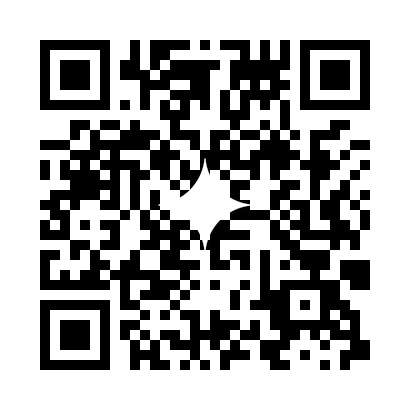

In [ ]:
# 1. Generate the base QR code using the NEW short link
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=10,
    border=4,
)
qr.add_data(short_link)
qr.make(fit=True)
base_img = qr.make_image(fill_color="black", back_color="white").convert("RGBA")

# 2. Process the Logo
logo_path = os.path.join(save_directory, logo_filename)
qr_output_path = os.path.join(save_directory, "final_short_qr_with_logo.png")

try:
    logo = Image.open(logo_path).convert("RGBA")
    
    # Execute the background removal if the toggle is True
    if remove_white_background:
        datas = logo.getdata()
        new_data = []
        for item in datas:
            if item[0] == 255 and item[1] == 255 and item[2] == 255:
                new_data.append((255, 255, 255, 0))
            else:
                new_data.append(item)
        logo.putdata(new_data)
        print("Background removed from logo.")

    # 3. Resize and Paste the Logo
    qr_width, qr_height = base_img.size
    logo_max_size = qr_width // 4
    
    logo_width, logo_height = logo.size
    aspect_ratio = logo_width / logo_height

    if logo_width > logo_height:
        new_width = logo_max_size
        new_height = int(new_width / aspect_ratio)
    else:
        new_height = logo_max_size
        new_width = int(new_height * aspect_ratio)

    logo = logo.resize((new_width, new_height), Image.LANCZOS)

    pos_x = (qr_width - new_width) // 2
    pos_y = (qr_height - new_height) // 2
    
    base_img.paste(logo, (pos_x, pos_y), logo)
    
    # 4. Save and Display
    base_img.save(qr_output_path)
    print(f"Success! QR Code saved to: {qr_output_path}")
    display(base_img)

except FileNotFoundError:
    print(f"ERROR: Could not find '{logo_filename}' in your folder. Double-check Cell 2!")